# Switching Performance Probe (No Contact)

Where does the time go in a switched `MultiComponent` run, and how much of the model time is
actually kept?

This notebook is the cheap sibling of `06_casestudy_performance.ipynb`. It runs the controlled
pendulum **without wall contact**, with a plant that holds only the **FEM** and **FMU** models, and
switches between them through **generated region boundaries** so each transition is localized by the
hybrid algorithm rather than snapped to the macro grid.

Mode conditions, on the pendulum angle, for the default `inner` region:

| Condition | Active model |
|---|---|
| `abs(theta) <= 10 deg` | FEM |
| `abs(theta) > 10 deg` | FMU |

Dropping contact removes the expensive penalty-contact solve and the `wall_hit` event chain, so what
remains is the cost of the models themselves plus the orchestration around them. It also makes a run
cheap enough to repeat, which is what turns this from a probe into a measurement.

Two cases are measured, not one:

- **Full FEM** - the FEM pendulum drives the whole horizon. This is the reference.
- **Switched FEM/FMU** - the region map hands the horizon between the two models.

Every model call is attributed to the algorithm phase that issued it, so accepted work is separated
from work that is computed and then rolled back. That separation is the point of the notebook; it is
what `issues.md` tracks as EVID-01.

## Setup

In [2]:
from dataclasses import dataclass, field
from functools import wraps
from pathlib import Path
from time import perf_counter_ns
import gc
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))
# plot_setup.py lives next to this notebook, which is not the working directory
# when the notebook is executed headlessly (nbmake, papermill).
sys.path.insert(0, str(_repo / "notebooks"))

from plot_setup import FULL_WIDTH, set_professional_style

plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum, FMUPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, FMUComponent, System
from syssimx.core.multi_comp import MultiComponent
from syssimx.system.algorithms import GaussSeidelAlgorithm, HybridAlgorithm

_repo

WindowsPath('c:/Users/flori/source/repos/FlorianFrech/SystemSimulation')

In [3]:
PLATFORM = sys.platform
DEMO_DIR = _repo / "demos" / "ControlledPendulum"
FMU_DIR = DEMO_DIR / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {f.stem: f for f in subdir.glob("*.fmu")}
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths)

['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Configuration

`THETA_SWITCH_DEG` is the mode boundary. The setpoint amplitude is 20 deg, so the pendulum crosses a
10 deg boundary several times per run, unlike the contact scenario which produced only two switches.

The switching band is the sole chatter guard. A full-band recrossing remains a valid transition
regardless of how little time has elapsed since the preceding switch.

`EVENT_TOL_VALUE` is **derived** from the indicator's rate and `EVENT_TOL_TIME` rather than picked by
hand. The reason is in the note under *Region boundaries*: the acceptance gate and the bisection
tolerance are coupled, and a hand-picked pair silently drops switches when it goes wrong.

> **Absolute timings are environment-sensitive; report the ratios.** Compare only runs that share
> `BENCHMARK_ENV`, and never compare a single cold run against a warmed median.

In [ ]:
T0 = 0.0
T_END = 0.4
MACRO_DT = 1e-3
FEM_INTERNAL_DT = 1e-3

# Setpoint shape. Used to derive the event tolerance and the region occupancy
# table, so it has to match the SetPoint FMU actually wired into the loop below.
THETA_AMPLITUDE_DEG = 20.0
SETPOINT_FREQ_HZ = 3.0

THETA_SWITCH_DEG = 10.0
SWITCH_BAND_DEG = 1.0    # hysteresis band around the boundary

# Which side of the boundary runs the expensive model.
#   "inner" -> FEM while |theta| <= threshold  (near vertical, max angular rate)
#   "outer" -> FEM while |theta| >  threshold  (max deflection and gravity torque)
# For a 20 deg amplitude the FEM share is 33 % inner versus 67 % outer, so the
# choice dominates the achievable speedup. See "Choosing the region" below.
FEM_REGION = "inner"
REGION_MODES = ("FMU", "FEM") if FEM_REGION == "outer" else ("FEM", "FMU")

FMU_SOLVER = "cvode"

# N_WARMUP = 1, N_REPEATS = 5 for a citable result; 3 keeps the notebook short
# while still giving a median and a drift check.
N_WARMUP = 1
N_REPEATS = 5

OUT_DIR = _repo / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Bisection stops once the located interval is this narrow. The default 1e-8
# costs ~17 model evaluations per switch to resolve a time that nothing needs to
# that precision; 1e-5 is still 1 % of a macro step and costs ~7.
EVENT_TOL_TIME = 1e-5

# Event-collection tolerance, in the indicator's own units (degrees here).
# After bisection, HybridAlgorithm._collect_events_at_time accepts an event only
# if abs(indicator) <= tol_value. Bisection leaves a residual of about
# rate * tol_time, so the gate must sit above that or located switches are never
# dispatched. Derived, not guessed - see the note under "Region boundaries".
MAX_THETA_RATE_DEG_S = 2.0 * np.pi * SETPOINT_FREQ_HZ * THETA_AMPLITUDE_DEG
EVENT_TOL_MARGIN = 10.0
EVENT_TOL_VALUE = EVENT_TOL_MARGIN * MAX_THETA_RATE_DEG_S * EVENT_TOL_TIME

BENCHMARK_ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "n_warmup": N_WARMUP,
    "n_repeats": N_REPEATS,
    "t_end": T_END,
    "macro_dt": MACRO_DT,
    "fem_internal_dt": FEM_INTERNAL_DT,
    "fem_region": FEM_REGION,
    "theta_switch_deg": THETA_SWITCH_DEG,
    "switch_band_deg": SWITCH_BAND_DEG,
    "fmu_solver": FMU_SOLVER,
    "event_tol_time": EVENT_TOL_TIME,
    "event_tol_value": EVENT_TOL_VALUE,
}

BENCHMARK_ENV

{'python': '3.13.5',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 165 Stepping 2, GenuineIntel',
 'n_warmup': 1,
 'n_repeats': 3,
 't_end': 0.4,
 'macro_dt': 0.001,
 'fem_internal_dt': 0.001,
 'fem_region': 'inner',
 'theta_switch_deg': 10.0,
 'switch_band_deg': 1.0,
 'fmu_solver': 'cvode',
 'event_tol_time': 1e-05,
 'event_tol_value': 0.03769911184307752}

## Plant: FEM + FMU only

`MasterPendulum` always constructs all three backends, including OpenSim. This probe needs two, so
it uses a local `MultiComponent` with just the FEM and FMU pendulums.

Two pieces of `MasterPendulum` are kept because they are not optional:

- **FEM is initialized first.** It derives mass, inertia, and equivalent length from its mesh, and
  the FMU has to be parameterised from those values or the two models describe different pendulums.
- **`_adapt_state` renames the state.** The FMU takes initial conditions (`theta_start`,
  `omega_start`), while the FEM uses the running state (`theta`, `omega`).

The plant declares one ordered region map, which privately generates the localized boundaries.

In [5]:
class SwitchingPendulum(MultiComponent):
    """FEM/FMU pendulum pair with event-localized mode switching."""

    def __init__(self, name="Pendulum", initial_mode="FEM", fmu_solver=FMU_SOLVER):
        self.fem = FEMPendulum(name="FEM_Pendulum")
        self.fmu = FMUPendulum(name="FMU_Pendulum", solver=fmu_solver)

        super().__init__(
            name=name,
            models={"FEM": self.fem, "FMU": self.fmu},
            initial_mode=initial_mode,
            group="Plant",
        )

        self._unify_ports()
        self._initialize_ports_from_specs()
        self.parameters.update({
            "FEM": self.fem.get_parameters(),
            "FMU": self.fmu.get_parameters(),
        })

    def _initialize_component(self, t0):
        # FEM first: its mesh determines the physical parameters the FMU needs.
        self.fem.set_parameters(**self.parameters.get("FEM", {}))
        self.fem.initialize(t0)
        self._sync_fmu_from_fem()
        self.fmu.initialize(t0)
        self.direct_feedthrough = self.active_comp.direct_feedthrough

    def _sync_fmu_from_fem(self):
        self.fmu.set_parameters(
            theta_start=np.deg2rad(self.fem.init_params.angular_position_deg),
            omega_start=self.fem.init_params.angular_velocity,
            m=self.fem.mass,
            L=self.fem._equivalent_length,
            J=self.fem.inertia,
            g=9.81 if self.fem._use_gravity else 0.0,
        )

    def _adapt_state(self, state, target_mode):
        if target_mode == "FMU":
            return {
                "theta_start": state["theta"],
                "omega_start": state["omega"],
                "tau": state["tau"],
            }
        return state

In [6]:
def make_fem_parameters():
    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = 0.0

    sim_params = config.SimulationParameters()
    sim_params.tau = FEM_INTERNAL_DT
    sim_params.t_end = T_END
    sim_params.with_contact = False      # no wall: this is the point of the scenario
    sim_params.use_gravity = True

    anim_params = config.AnimationParameters()
    anim_params.animate = False

    return {"init_params": init_params, "sim_params": sim_params, "anim_params": anim_params}

## Region boundaries

The mode boundary is `THETA_SWITCH_DEG`, applied as a **band** rather than a single value:

$$h_\mathrm{FEM}(\theta) = |\theta| - (\theta_\mathrm{sw} + \Delta),
\qquad
h_\mathrm{FMU}(\theta) = |\theta| - (\theta_\mathrm{sw} - \Delta)$$

FEM takes over on a **rising** crossing of the upper edge; FMU takes back over on a **falling**
crossing of the lower edge. This is an ordinary Schmitt trigger, and it is also **required** here -
see the second note below.

The indicator is evaluated against the **wrapper**, so it reads the unified `theta` output and works
regardless of which sub-model is active. Port values are Pint quantities, hence the unwrap.

> **The event tolerance must match the indicator's units and the bisection tolerance.** After
> bisection localizes a crossing, `HybridAlgorithm._collect_events_at_time` only accepts an event if
> `abs(indicator) <= algorithm.tol_value`, whose default is `1e-6`. This indicator is in **degrees**
> and moves at up to $2\pi f A \approx 377\ \mathrm{deg/s}$, so bisecting only to `tol_time` leaves a
> residual of roughly `rate * tol_time`. The switch is then located but never dispatched.
>
> The two tolerances are therefore coupled, and neither may be chosen alone:
>
> | `tol_time` | residual at the located time | smallest workable `tol_value` |
> |---|---|---|
> | `1e-8` | `~4e-6` deg | `~1e-5` |
> | `1e-5` (used here) | `~4e-3` deg | `~4e-2` |
>
> This is why `EVENT_TOL_VALUE` is derived above as `margin * rate * tol_time` rather than typed in.
> A hand-picked pair that happens to work at one `tol_time` silently drops switches at another, and
> **a partial switch count is the dangerous failure: it looks like it works.** The self-check below
> counts boundary crossings in the recorded trajectory and compares them against the switches the
> algorithm actually dispatched, so this failure cannot pass quietly.
>
> If you rewrite the indicator in radians or normalise it, the derivation still holds - only
> `MAX_THETA_RATE_DEG_S` changes units.

> **Why the band is required, not merely good practice.** If both indicators share one threshold,
> they are zero at the *same* instant. `_collect_events_at_time` accepts any indicator near zero
> without consulting its direction, so both switch events are dispatched together. The hybrid
> algorithm then sees two events on one component and runs
> `_verify_event_commutativity_dynamically`, which snapshots the component, replays each ordering,
> and restores between them. But handling a switch event *changes which sub-model is active*, so the
> second restore pushes an FMU snapshot into the FEM model and fails with
> `Incompatible snapshot mode`.
>
> Measured on the same 20 deg sine:
>
> | Band | Instants with two simultaneous switch events | Result |
> |---|---|---|
> | `0.0` | 1 | `ValueError: Incompatible snapshot mode` |
> | `0.5` | 0 | 4 switches, correctly alternating |
>
> Separating the thresholds makes the two zeros distinct, so the situation cannot arise. Two
> mutually exclusive mode requests at the same instant is a modelling error in any case - order
> would decide the outcome.

In [7]:
def theta_deg(comp):
    """Wrapper angle in degrees, unwrapping the Pint quantity."""
    value = comp.outputs["theta"].get()
    if value is None:
        return 0.0
    return float(np.rad2deg(getattr(value, "magnitude", value)))


def switching_key(comp):
    """Region signal: absolute deflection in degrees."""
    return abs(theta_deg(comp))


# The FEM plant must not be perturbed before its torque boundary is assembled,
# so the feedthrough map is declared rather than detected.
PLANT_DIRECT_FEEDTHROUGH = {"theta": (), "omega": (), "alpha": ("tau",)}
PLANT_NAME = "Pendulum"


def declare_plant_feedthrough(plant):
    plant.direct_feedthrough = {
        output: set(inputs) for output, inputs in PLANT_DIRECT_FEEDTHROUGH.items()
    }
    return plant

## System factory

Both cases use the same closed loop: setpoint, PID, drive, plant, and the sensor chain. Only the
plant is exchanged. No event connections are needed - there is no `wall_hit`, and the switch events
are handled by the wrapper itself.

Building the system inside a factory rather than at cell scope is what makes repeated, independent
runs possible. Each repetition gets a fresh system, fresh components, and fresh timers.

> **The two cases do not run the same master algorithm, and that is not a defect - it is the
> result.** The switched plant owns generated region boundaries, so it is an event source and
> `System.initialize()` selects `HybridAlgorithm`. The full-FEM plant without contact has no event
> indicators at all, so it stays on `GaussSeidelAlgorithm` and performs **no trial steps**. Forcing
> the hybrid algorithm onto the baseline would not change that: `_detect_crossings` iterates over
> `system.event_sources`, and with that list empty it finds nothing and falls straight through to
> the Gauss-Seidel step. The asymmetry is a property of the scenario, not a configuration choice.
>
> A plain `run_s` ratio therefore mixes the model saving with an algorithm difference. The summary
> below reports both that ratio and an `accepted_speedup` computed from accepted-phase solve time
> only, which is algorithm-independent and is the defensible claim.

In [8]:
def create_common_components():
    setpoint = FMUComponent(
        name="Setpoint", fmu_path=fmu_paths["Trajectories"]["SetPoint"], group="Reference"
    )
    pid = FMUComponent(
        name="PID", fmu_path=fmu_paths["Controllers"]["PIDControllerReset_euler"],
        group="Controller",
    )
    drive = FMUComponent(
        name="Drive", fmu_path=fmu_paths["Actuators"]["DriveDynamic"], group="Actuator"
    )
    angle_sensor = FMUComponent(
        name="Angle Sensor", fmu_path=fmu_paths["Sensors"]["AngleSensor"], group="Sensors"
    )
    angle_decoder = FMUComponent(
        name="Angle Decoder", fmu_path=fmu_paths["Sensors"]["AngleDecoder"],
        group="Signal Processing",
    )
    return setpoint, pid, drive, angle_sensor, angle_decoder


def assemble_system(plant, case_name):
    setpoint, pid, drive, angle_sensor, angle_decoder = create_common_components()

    system = System(name=case_name)
    for comp in (setpoint, pid, drive, plant, angle_sensor, angle_decoder):
        system.add_component(comp)

    for conn in [
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection(PLANT_NAME, "theta", "Angle Sensor", "theta"),
        Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
        Connection("Angle Decoder", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", PLANT_NAME, "tau"),
        Connection(PLANT_NAME, "omega", "Drive", "omega"),
    ]:
        system.add_connection(conn)

    system.initialize(t0=T0)

    # Tolerances are set after initialize() because that is when the algorithm
    # instance exists. Only the hybrid algorithm carries them; assigning them to
    # a Gauss-Seidel instance would create a dead attribute that looks tuned.
    if isinstance(system.algorithm, HybridAlgorithm):
        system.algorithm.tol_value = EVENT_TOL_VALUE
        system.algorithm.tol_time = EVENT_TOL_TIME

    return system


def build_switched_case():
    plant = SwitchingPendulum(name=PLANT_NAME)
    plant.set_switch_regions(
        key=switching_key,
        breakpoints=(THETA_SWITCH_DEG,),
        modes=REGION_MODES,
        band=SWITCH_BAND_DEG,
    )
    plant.set_parameters(**{"FEM": make_fem_parameters()})
    declare_plant_feedthrough(plant)

    system = assemble_system(plant, "Switched FEM/FMU")
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}


def build_baseline_case():
    plant = FEMPendulum(name=PLANT_NAME, group="Plant")
    plant.set_parameters(**make_fem_parameters())
    declare_plant_feedthrough(plant)

    system = assemble_system(plant, "Full FEM")
    return system, plant, {"FEM": plant}

## Instrumentation

Two questions have to be answered separately, so there are two levels of timer.

**How much time is spent solving?** `_do_step_internal` is wrapped on each *model* - the FEM and FMU
pendulums themselves, never the wrapper alone. This is the only measurement that means the same
thing in both cases, because in the switched case the algorithm talks to the `MultiComponent` while
in the baseline it talks to the FEM directly.

**Which work survives?** Every model call is tagged with the algorithm phase that issued it. The
phase is established by wrapping the algorithm's own entry points, not inferred:

| Phase | Entry point | Kept? |
|---|---|---|
| `accepted` | `GaussSeidelAlgorithm.step` | yes - this is the solution |
| `trial` | `HybridAlgorithm._detect_crossings` | no - snapshotted and restored |
| `bisection` | `HybridAlgorithm._locate_event_time` | no - restored after localization |
| `events` | `HybridAlgorithm.handle_events` | yes - discrete update at the event |

Everything left over, `run_s - solve_s`, is orchestration: port and unit handling, history recording,
event bookkeeping, and mode selection.

One extra number falls out for free. In the switched case the wrapper's own `_do_step_internal` is
timed as well; it delegates through `active_comp.do_step()`, which is `_do_step_internal` **plus**
`_update_output_states()` and conditional history recording. `delegation_s` is that difference, and
it is the per-call price of wrapping two models in one component.

In [9]:
ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER = "accepted", "trial", "bisection", "events", "other"
PHASES = (ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER)
DISCARDED_PHASES = (TRIAL, BISECTION)


class PhaseTracker:
    """Which algorithm phase is executing right now.

    A stack rather than a scalar, so a nested entry point reports the innermost
    phase and restores its caller's on the way out.
    """

    def __init__(self):
        self._stack = []

    @property
    def phase(self):
        return self._stack[-1] if self._stack else OTHER

    def wrap(self, phase, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            self._stack.append(phase)
            try:
                return func(*args, **kwargs)
            finally:
                self._stack.pop()

        return wrapper


def instrument_algorithm(algorithm, tracker):
    """Label every model call with the algorithm phase that issued it."""
    if isinstance(algorithm, HybridAlgorithm):
        algorithm._detect_crossings = tracker.wrap(TRIAL, algorithm._detect_crossings)
        algorithm._locate_event_time = tracker.wrap(BISECTION, algorithm._locate_event_time)
        algorithm.handle_events = tracker.wrap(EVENTS, algorithm.handle_events)
        accepted_stepper = algorithm.gauss_seidel_algorithm
    elif isinstance(algorithm, GaussSeidelAlgorithm):
        accepted_stepper = algorithm
    else:
        raise TypeError(f"Unsupported algorithm: {type(algorithm).__name__}")
    accepted_stepper.step = tracker.wrap(ACCEPTED, accepted_stepper.step)


@dataclass
class PhaseTimer:
    """Wall time inside one component's `_do_step_internal`, split by phase."""

    label: str
    wall_ns: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))
    n_calls: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))

    @property
    def wall_s(self):
        return sum(self.wall_ns.values()) * 1e-9

    @property
    def calls(self):
        return sum(self.n_calls.values())

    def phase_s(self, phase):
        return self.wall_ns[phase] * 1e-9


def instrument_step(comp, label, tracker):
    timer = PhaseTimer(label=label)
    original = comp._do_step_internal

    @wraps(original)
    def timed(t, dt, *args, **kwargs):
        phase = tracker.phase
        start = perf_counter_ns()
        try:
            return original(t, dt, *args, **kwargs)
        finally:
            timer.wall_ns[phase] += perf_counter_ns() - start
            timer.n_calls[phase] += 1

    comp._do_step_internal = timed
    return timer

## Run one case

In [10]:
def run_case(build_case, case_name, repeat, *, warmup=False, keep_result=False):
    gc.collect()

    setup_start = perf_counter_ns()
    system, plant, models = build_case()
    setup_s = (perf_counter_ns() - setup_start) * 1e-9

    tracker = PhaseTracker()
    instrument_algorithm(system.algorithm, tracker)
    model_timers = {name: instrument_step(comp, name, tracker) for name, comp in models.items()}
    # The wrapper is only a distinct object in the switched case.
    wrapper_timer = (
        instrument_step(plant, "wrapper", tracker) if isinstance(plant, MultiComponent) else None
    )

    # The region map, not the constructor argument, decides which model starts.
    # `_reconcile_initial_region()` derives it from the switching signal at t0,
    # so it has to be read back rather than assumed.
    initial_mode = plant.active_mode if isinstance(plant, MultiComponent) else "FEM"

    sim_time = T_END - T0
    label = f"{'warmup' if warmup else 'repeat'} {repeat + 1} - {case_name}"

    with tqdm(total=sim_time, desc=label, unit=" sim s", leave=True) as bar:
        progressed = 0.0

        def on_progress(t, _tf):
            nonlocal progressed
            now = min(max(t - T0, 0.0), sim_time)
            bar.update(now - progressed)
            progressed = now

        run_start = perf_counter_ns()
        system.run(T0, T_END, MACRO_DT, progress=on_progress)
        run_s = (perf_counter_ns() - run_start) * 1e-9

    solve_s = sum(timer.wall_s for timer in model_timers.values())
    plant_s = wrapper_timer.wall_s if wrapper_timer is not None else solve_s
    sync_events = list(getattr(plant, "sync_events", []))

    row = {
        "case": case_name,
        "repeat": repeat,
        "warmup": warmup,
        "algorithm": type(system.algorithm).__name__,
        "initial_mode": initial_mode,
        "setup_s": setup_s,
        "run_s": run_s,
        "solve_s": solve_s,
        "delegation_s": plant_s - solve_s,
        "overhead_s": run_s - solve_s,
        "n_switches": len(sync_events),
    }
    for phase in PHASES:
        row[f"solve_{phase}_s"] = sum(timer.phase_s(phase) for timer in model_timers.values())
        row[f"calls_{phase}"] = sum(timer.n_calls[phase] for timer in model_timers.values())
    for name, timer in model_timers.items():
        row[f"{name.lower()}_solve_s"] = timer.wall_s
        row[f"{name.lower()}_calls"] = timer.calls

    result = None
    if keep_result:
        t_hist, data = system.get_history()[plant.name]
        result = {
            "case": case_name,
            "t": np.asarray(t_hist, dtype=float),
            "theta_deg": np.rad2deg(np.asarray(data["theta"], dtype=float)),
            "sync_events": sync_events,
            "initial_mode": initial_mode,
        }

    return row, result

## Execute

Warm-up runs are excluded from every summary. The first evaluated run of each case is kept for the
trajectory plot.

In [11]:
case_builders = {
    "Full FEM": build_baseline_case,
    "Switched FEM/FMU": build_switched_case,
}

rows = []
representative = {}

for i in range(N_WARMUP):
    for case_name, builder in case_builders.items():
        row, _ = run_case(builder, case_name, i, warmup=True)
        rows.append(row)

for i in range(N_REPEATS):
    for case_name, builder in case_builders.items():
        keep_result = i == 0
        row, result = run_case(builder, case_name, i, keep_result=keep_result)
        rows.append(row)
        if keep_result:
            representative[case_name] = result

df_runs = pd.DataFrame(rows)
df_eval = df_runs.loc[~df_runs["warmup"]].copy()

display(
    df_eval[
        ["case", "repeat", "algorithm", "initial_mode", "run_s", "solve_s",
         "overhead_s", "n_switches"]
    ]
    .style.format({"run_s": "{:.2f}", "solve_s": "{:.2f}", "overhead_s": "{:.2f}"})
    .hide(axis="index")
)

warmup 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

warmup 1 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 3 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 3 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

case,repeat,algorithm,initial_mode,run_s,solve_s,overhead_s,n_switches
Full FEM,0,GaussSeidelAlgorithm,FEM,36.88,35.45,1.43,0
Switched FEM/FMU,0,HybridAlgorithm,FEM,30.53,25.58,4.95,5
Full FEM,1,GaussSeidelAlgorithm,FEM,36.64,35.21,1.43,0
Switched FEM/FMU,1,HybridAlgorithm,FEM,33.07,27.96,5.11,5
Full FEM,2,GaussSeidelAlgorithm,FEM,42.92,41.42,1.50,0
Switched FEM/FMU,2,HybridAlgorithm,FEM,32.09,26.99,5.11,5


## Drift check

`FMUComponent` no longer releases its native instance or its extraction directory (`issues.md`
HARD-05: freeing the CVODE pendulum FMU corrupts the heap). Every repetition here builds six FMUs,
and none of them are ever released, so resources accumulate across the benchmark for the lifetime of
the kernel.

A median does not protect against a *drifting* series - it just picks the middle of the drift. This
compares the first and last evaluated repetition of each case.

In [12]:
drift = (
    df_eval.sort_values("repeat")
    .groupby("case", sort=False)["run_s"]
    .agg(first_s="first", last_s="last", median_s="median")
)
drift["drift"] = (drift["last_s"] - drift["first_s"]) / drift["first_s"]

display(
    drift.style.format(
        {"first_s": "{:.2f}", "last_s": "{:.2f}", "median_s": "{:.2f}", "drift": "{:+.1%}"}
    )
)

DRIFT_LIMIT = 0.10
drifted = drift.index[drift["drift"].abs() > DRIFT_LIMIT].tolist()
if drifted:
    print(
        f"WARNING: run time drifts by more than {DRIFT_LIMIT:.0%} across repetitions for "
        f"{', '.join(drifted)}."
    )
    print("         The medians below are not trustworthy. Run each repetition in a fresh")
    print("         process, or raise N_REPEATS and inspect the trend before quoting a number.")
else:
    print(f"No repetition drifts by more than {DRIFT_LIMIT:.0%}; the medians below are usable.")

,first_s,last_s,median_s,drift
case,,,,
Full FEM,36.88,42.92,36.88,+16.4%
Switched FEM/FMU,30.53,32.09,32.09,+5.1%


         The medians below are not trustworthy. Run each repetition in a fresh
         process, or raise N_REPEATS and inspect the trend before quoting a number.


## Where the time went

In [13]:
summary = (
    df_eval
    .groupby("case", sort=False)
    .agg(
        run_s=("run_s", "median"),
        solve_s=("solve_s", "median"),
        solve_accepted_s=("solve_accepted_s", "median"),
        overhead_s=("overhead_s", "median"),
        delegation_s=("delegation_s", "median"),
        n_switches=("n_switches", "median"),
    )
)

baseline = summary.loc["Full FEM"]
summary["run_speedup"] = baseline["run_s"] / summary["run_s"]
summary["solve_speedup"] = baseline["solve_s"] / summary["solve_s"]
summary["accepted_speedup"] = baseline["solve_accepted_s"] / summary["solve_accepted_s"]
summary["solve_share"] = summary["solve_s"] / summary["run_s"]

display(
    summary.style.format({
        "run_s": "{:.2f}", "solve_s": "{:.2f}", "solve_accepted_s": "{:.2f}",
        "overhead_s": "{:.2f}", "delegation_s": "{:.2f}", "n_switches": "{:.0f}",
        "run_speedup": "{:.2f}x", "solve_speedup": "{:.2f}x", "accepted_speedup": "{:.2f}x",
        "solve_share": "{:.1%}",
    })
)

,run_s,solve_s,solve_accepted_s,overhead_s,delegation_s,n_switches,run_speedup,solve_speedup,accepted_speedup,solve_share
case,,,,,,,,,,
Full FEM,36.88,35.45,35.45,1.43,0.00,0,1.00x,1.00x,1.00x,96.1%
Switched FEM/FMU,32.09,26.99,12.48,5.11,0.13,5,1.15x,1.31x,2.84x,84.1%


In [14]:
phase_rows = []
for case_name in df_eval["case"].unique():
    sub = df_eval.loc[df_eval["case"] == case_name]
    for phase in PHASES:
        wall_s = float(sub[f"solve_{phase}_s"].median())
        calls = float(sub[f"calls_{phase}"].median())
        if calls == 0 and wall_s == 0.0:
            continue
        phase_rows.append({"case": case_name, "phase": phase, "wall_s": wall_s, "calls": calls})

phases_df = pd.DataFrame(phase_rows)
solve_total = phases_df.groupby("case")["wall_s"].transform("sum")
phases_df["share_of_solve"] = phases_df["wall_s"] / solve_total
phases_df["ms_per_call"] = 1e3 * phases_df["wall_s"] / phases_df["calls"].clip(lower=1)

display(
    phases_df.style.format({
        "wall_s": "{:.2f}", "calls": "{:.0f}", "share_of_solve": "{:.1%}",
        "ms_per_call": "{:.1f}",
    }).hide(axis="index")
)

discarded = (
    phases_df.loc[phases_df["phase"].isin(DISCARDED_PHASES)].groupby("case")["wall_s"].sum()
    / phases_df.groupby("case")["wall_s"].sum()
).reindex(summary.index).fillna(0.0)

for case_name, share in discarded.items():
    print(f"{case_name:<20} discarded model time (trial + bisection): {share:.1%}")

case,phase,wall_s,calls,share_of_solve,ms_per_call
Full FEM,accepted,35.45,400,100.0%,88.6
Switched FEM/FMU,accepted,12.48,405,46.6%,30.8
Switched FEM/FMU,trial,13.27,405,49.5%,32.8
Switched FEM/FMU,bisection,1.07,23,4.0%,46.4


Full FEM             discarded model time (trial + bisection): 0.0%
Switched FEM/FMU     discarded model time (trial + bisection): 53.4%


## Self-check: were all switches dispatched?

The acceptance gate described under *Region boundaries* fails quietly. This counts how often the
recorded trajectory crosses the boundary and compares that against the switches the algorithm
actually committed. A shortfall means `EVENT_TOL_VALUE` is too tight for the chosen
`EVENT_TOL_TIME`, and it raises rather than letting a half-switched run reach the figure.

In [15]:
switched = representative["Switched FEM/FMU"]

boundary_sign = np.sign(np.abs(switched["theta_deg"]) - THETA_SWITCH_DEG)
boundary_sign = boundary_sign[boundary_sign != 0]
crossings = int(np.count_nonzero(np.diff(boundary_sign) != 0))
n_switches = len(switched["sync_events"])

print(f"initial mode reported by the region map  : {switched['initial_mode']}")
print(f"|theta| crossings of {THETA_SWITCH_DEG:.0f} deg in trajectory : {crossings}")
print(f"switches dispatched by the algorithm     : {n_switches}")

if n_switches == 0:
    raise AssertionError(
        "No switches occurred; the switched case is not exercising the region map."
    )
if n_switches < crossings:
    raise AssertionError(
        f"Only {n_switches} of {crossings} boundary crossings were dispatched as switches. "
        f"EVENT_TOL_VALUE={EVENT_TOL_VALUE:.2e} is too tight for "
        f"EVENT_TOL_TIME={EVENT_TOL_TIME:.0e}; raise EVENT_TOL_MARGIN or tighten EVENT_TOL_TIME."
    )
print("OK: every boundary crossing produced a switch.")

initial mode reported by the region map  : FEM
|theta| crossings of 10 deg in trajectory : 5
switches dispatched by the algorithm     : 5
OK: every boundary crossing produced a switch.


## Mode timeline

`sync_events` records every completed switch. Because the switch is an event, each entry sits on the
located crossing of `|theta| = 10 deg` rather than on a macro-step boundary. The initial mode comes
from the plant after initialization, not from the constructor argument.

In [16]:
def mode_intervals(sync_events, initial_mode, t0, t_end):
    """`(t_left, t_right, mode)` intervals covering the whole horizon."""
    rows, mode, left = [], initial_mode, t0
    for event in sync_events:
        right = float(event["time"])
        rows.append((left, right, mode))
        mode, left = event["to_mode"], right
    rows.append((left, t_end, mode))
    return rows


intervals = mode_intervals(switched["sync_events"], switched["initial_mode"], T0, T_END)

sim_time = T_END - T0
active_time = {"FEM": 0.0, "FMU": 0.0}
for left, right, mode in intervals:
    active_time[mode] += max(0.0, right - left)

occupancy = pd.DataFrame([
    {"mode": mode, "sim_s": value, "share": value / sim_time}
    for mode, value in active_time.items()
])
display(occupancy.style.format({"sim_s": "{:.3f}", "share": "{:.1%}"}).hide(axis="index"))

mode,sim_s,share
FEM,0.144,36.1%
FMU,0.256,63.9%


## Figure

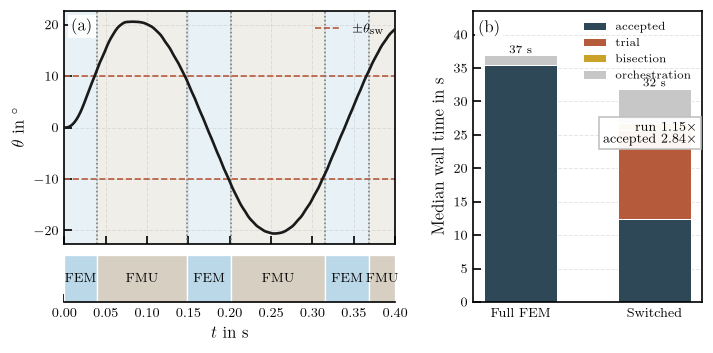

In [17]:
MODE_COLORS = {"FEM": "#bbd8e8", "FMU": "#d6cfc2"}
PHASE_COLORS = {
    ACCEPTED: "#2F4858",
    TRIAL: "#B65A3C",
    BISECTION: "#C9A227",
    EVENTS: "#7B6D8D",
    OTHER: "#9AA5A8",
}
OVERHEAD_COLOR = "0.78"
PANEL_LABEL_STYLE = dict(
    fontweight="bold", fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2),
)

fig = plt.figure(figsize=(FULL_WIDTH, 0.52 * FULL_WIDTH))
outer = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.28,
                         left=0.08, right=0.98, top=0.92, bottom=0.13)
left_grid = outer[0, 0].subgridspec(2, 1, height_ratios=[5, 1], hspace=0.08)
ax_traj = fig.add_subplot(left_grid[0, 0])
ax_mode = fig.add_subplot(left_grid[1, 0], sharex=ax_traj)
ax_bar = fig.add_subplot(outer[0, 1])

# --- (a) trajectory with mode shading ---------------------------------------
for left, right, mode in intervals:
    ax_traj.axvspan(left, right, color=MODE_COLORS[mode], alpha=0.35, zorder=0)
ax_traj.plot(switched["t"], switched["theta_deg"], color="#1a1a1a", lw=1.6, zorder=3)
for sign in (+1, -1):
    ax_traj.axhline(sign * THETA_SWITCH_DEG, color="#B65A3C", ls="--", lw=1.0,
                    label=r"$\pm\theta_\mathrm{sw}$" if sign > 0 else None)
for event in switched["sync_events"]:
    ax_traj.axvline(float(event["time"]), color="0.45", ls=":", lw=0.9, zorder=2)
ax_traj.set_ylabel(r"$\theta$ in $^\circ$")
ax_traj.set_xlim(T0, T_END)
ax_traj.grid(True, alpha=0.4)
ax_traj.tick_params(axis="x", labelbottom=False)
ax_traj.legend(loc="upper right", fontsize=8, frameon=False)

for left, right, mode in intervals:
    width = right - left
    if width <= 0:
        continue
    ax_mode.broken_barh([(left, width)], (0, 1), facecolors=MODE_COLORS[mode],
                        edgecolors="white", linewidth=0.8)
    if width / sim_time > 0.06:
        ax_mode.text(left + width / 2, 0.5, mode, ha="center", va="center", fontsize=8)
ax_mode.set_ylim(0, 1)
ax_mode.set_yticks([])
ax_mode.set_xlim(T0, T_END)
ax_mode.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_mode.grid(False)
for spine in ("left", "right", "top"):
    ax_mode.spines[spine].set_visible(False)

# --- (b) stacked wall time ---------------------------------------------------
cases = list(summary.index)
x = np.arange(len(cases))
bottom = np.zeros(len(cases))

for phase in PHASES:
    values = np.array([
        float(df_eval.loc[df_eval["case"] == case, f"solve_{phase}_s"].median())
        for case in cases
    ])
    if not np.any(values > 0):
        continue
    ax_bar.bar(x, values, bottom=bottom, width=0.55, color=PHASE_COLORS[phase],
               label=phase, edgecolor="white", linewidth=0.6)
    bottom += values

overhead = np.array([float(summary.loc[case, "overhead_s"]) for case in cases])
ax_bar.bar(x, overhead, bottom=bottom, width=0.55, color=OVERHEAD_COLOR,
           label="orchestration", edgecolor="white", linewidth=0.6)
bottom += overhead

for xi, total in zip(x, bottom):
    ax_bar.text(xi, total, f"{total:.0f} s", ha="center", va="bottom", fontsize=7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([c.replace(" FEM/FMU", "") for c in cases], fontsize=8)
ax_bar.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax_bar.set_ylim(0, bottom.max() * 1.18)
ax_bar.grid(True, axis="y", alpha=0.4)
ax_bar.legend(loc="upper right", fontsize=7, frameon=False)

run_speedup = summary.loc["Switched FEM/FMU", "run_speedup"]
accepted_speedup = summary.loc["Switched FEM/FMU", "accepted_speedup"]
ax_bar.text(
    0.98, 0.62,
    f"run ${run_speedup:.2f}" + r"\times$" + "\n"
    + f"accepted ${accepted_speedup:.2f}" + r"\times$",
    transform=ax_bar.transAxes, ha="right", va="top", fontsize=8,
    bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5),
)

for label, ax in [("(a)", ax_traj), ("(b)", ax_bar)]:
    ax.text(0.02, 0.97, label, transform=ax.transAxes, ha="left", va="top", **PANEL_LABEL_STYLE)

fig.savefig(OUT_DIR / "07_performance_nocontact.pdf", bbox_inches="tight")
plt.show()

## Choosing the region

For a sinusoidal setpoint of amplitude $A$, the share of the horizon spent outside a threshold
$\theta_\mathrm{sw}$ is

$$P(|\theta| > \theta_\mathrm{sw}) = \frac{2}{\pi}\arccos\!\left(\frac{\theta_\mathrm{sw}}{A}\right)$$

which at $A = 20^\circ$ and $\theta_\mathrm{sw} = 10^\circ$ gives 66.7 %. Putting FEM there means the
expensive model runs two-thirds of the time, and no orchestration tuning can recover that.

The table below is computed from **this run's** measured accepted FEM cost per call, so it tracks the
machine it was produced on. It counts accepted FEM solve time only, ignoring trial work, bisection,
and the FMU's own cost, so its `est_speedup` column is an **upper bound** on what the region choice
can deliver - compare it against the measured `accepted_speedup` above.

`inner` is the default here. It is also physically reasonable: near vertical the pendulum is at
maximum angular rate, so centrifugal loading and the resulting deflection peak there. `outer` is
equally defensible on gravity-torque and bending grounds - set `FEM_REGION` to whichever the physics
argument supports, knowing what it costs.

In [18]:
baseline_rows = df_eval.loc[df_eval["case"] == "Full FEM"]
baseline_accepted_calls = float(baseline_rows["calls_accepted"].median())
baseline_accepted_s = float(summary.loc["Full FEM", "solve_accepted_s"])
fem_ms_per_call = 1e3 * baseline_accepted_s / max(baseline_accepted_calls, 1.0)


def outer_share(theta_sw, amplitude=THETA_AMPLITUDE_DEG):
    """Share of a sine horizon spent with |theta| above `theta_sw`."""
    return 2.0 / np.pi * np.arccos(min(1.0, theta_sw / amplitude))


region_rows = []
for region, theta_sw in [("outer", 10.0), ("outer", 15.0), ("inner", 10.0), ("inner", 8.0)]:
    share_outside = outer_share(theta_sw)
    fem_share = share_outside if region == "outer" else 1.0 - share_outside
    est_s = fem_share * baseline_accepted_calls * fem_ms_per_call * 1e-3
    region_rows.append({
        "rule": f"{region}, {theta_sw:.0f} deg",
        "fem_share": fem_share,
        "est_accepted_fem_s": est_s,
        "est_speedup": baseline_accepted_s / est_s if est_s > 0 else np.nan,
        "current": region == FEM_REGION and bool(np.isclose(theta_sw, THETA_SWITCH_DEG)),
    })

print(f"measured accepted FEM cost: {fem_ms_per_call:.1f} ms per call "
      f"over {baseline_accepted_calls:.0f} calls")
display(
    pd.DataFrame(region_rows).style.format({
        "fem_share": "{:.1%}", "est_accepted_fem_s": "{:.1f}", "est_speedup": "{:.2f}x",
    }).hide(axis="index")
)

measured accepted FEM cost: 88.6 ms per call over 400 calls


rule,fem_share,est_accepted_fem_s,est_speedup,current
"outer, 10 deg",66.7%,23.6,1.50x,False
"outer, 15 deg",46.0%,16.3,2.17x,False
"inner, 10 deg",33.3%,11.8,3.00x,True
"inner, 8 deg",26.2%,9.3,3.82x,False


## Reading the result

Read the tables above rather than any number written into this prose - they are regenerated on every
execution, and absolute timings move with interpreter and machine state.

**Is the wrapper the bottleneck?** Compare `overhead_s` against `solve_s` in the summary, and
`delegation_s` against `overhead_s`. `delegation_s` is the part of orchestration that exists only
because two models are wrapped in one component: each call the algorithm makes on the wrapper
delegates through `active_comp.do_step()`, which adds `_update_output_states()` and conditional
history recording on top of the solve.

**How much model time is thrown away?** The phase table answers this directly, and the `discarded`
line under it aggregates it. Two mechanisms produce it:

1. **Trial steps.** `_detect_crossings` advances every event source across the macro step, evaluates
   the indicators, and restores the snapshot. If no crossing is found, Gauss-Seidel then steps the
   same interval again. On an event-free macro step the model is solved twice for one result. This
   is why the switched case can show `calls_trial` close to `calls_accepted`.
2. **Bisection.** Each located event costs about $\log_2(\Delta t / \mathtt{tol\_time})$ further
   evaluations. `EVENT_TOL_TIME` trades placement precision against that count; at $\Delta t =
   10^{-3}$ and `tol_time` $= 10^{-5}$ that is roughly 7 evaluations per switch, against 17 at the
   default $10^{-8}$.

The baseline runs Gauss-Seidel and therefore has **no** trial or bisection rows at all. That is the
asymmetry the `accepted_speedup` column exists to remove: it compares only the work both cases keep.

For a component that already resolves its own events internally - such as `FEMPendulum` *with*
contact, which reduces its sub-step near the wall and calls `report_internal_event` - bisection is
avoidable entirely. `_locate_event_time` accepts the reported interval directly when it is already
narrower than `tol_time`. That shortcut only fires if `tol_time` is at least as coarse as the
component's internal sub-step. This notebook runs without contact, so the shortcut never applies
here; `06_casestudy_performance.ipynb` is where it matters.

To attribute the remaining orchestration cost, profile rather than adding more manual timers:

```python
import cProfile, pstats
system, plant, models = build_switched_case()
cProfile.run("system.run(T0, T_END, MACRO_DT)", "perf.prof")
pstats.Stats("perf.prof").sort_stats("cumulative").print_stats(25)
```